<a href="https://colab.research.google.com/github/IrineuACgasoso/Projeto-2-Estatistica/blob/main/projeto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJETO 2 - Manutenção Preditiva Industrial

##**Seção 1 - Introdução**

## 1.1 Contextualização
A manutenção preditiva é uma estratégia utilizada na indústria para prever possíveis falhas em máquinas e equipamentos antes que elas aconteçam. Essa abordagem utiliza dados coletados por sensores e sistemas de monitoramento para identificar padrões que indiquem desgaste ou risco de falha.

Sua importância está relacionada à redução de custos com manutenção corretiva, diminuição do tempo de parada das máquinas e aumento da eficiência operacional. O dataset utilizado neste projeto representa informações de funcionamento de máquinas industriais, contendo variáveis relacionadas ao desempenho, temperatura, desgaste e falhas dos equipamentos.

## 1.2 Objetivo
*É possível prever se uma máquina irá falhar com base nas suas condições operacionais?*

O objetivo deste projeto é analisar os dados de manutenção preditiva e identificar padrões associados às falhas das máquinas. Busca-se compreender quais variáveis possuem maior relação com a ocorrência de falhas e como essas informações podem auxiliar na prevenção de problemas industriais.

## 1.3 Descrição dos Dados

O dataset utilizado contém informações sobre o funcionamento de máquinas industriais utilizadas em um ambiente de produção. Os dados incluem variáveis operacionais, condições de temperatura, velocidade de rotação e indicadores de falha.

### Fonte dos Dados

O conjunto de dados foi obtido de uma base pública voltada para estudos de manutenção preditiva e análise de falhas em equipamentos industriais.

Referência: S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," AI4I 2020.

### Dicionário das Variáveis

| Coluna | Descrição |
|---|---|
| UDI | Identificador único de cada registro |
| Product ID | Identificação do produto ou máquina |
| Type | Tipo de máquina ou categoria do equipamento |
| Air temperature [K] | Temperatura do ar em Kelvin |
| Process temperature [K] | Temperatura do processo em Kelvin |
| Rotational speed [rpm] | Velocidade de rotação em rotações por minuto |
| Torque [Nm] | Torque aplicado na máquina em Newton-metro |
| Tool wear [min] | Tempo de desgaste da ferramenta em minutos |
| Machine failure | Indica se ocorreu falha geral na máquina |
| TWF | Falha por desgaste da ferramenta |
| HDF | Falha por dissipação de calor |
| PWF | Falha por potência |
| OSF | Falha por sobrecarga |
| RNF | Falha aleatória |





---


## **Seção 2 — Análise Exploratória de Dados (Univariada)**




### **2.1 Carregamento e Limpeza dos Dados**

In [53]:
url <- "https://raw.githubusercontent.com/IrineuACgasoso/Projeto-2-Estatistica/refs/heads/main/ai4i2020.csv"

install.packages("ggplot2")
library(ggplot2)

# TEMA DOS GRÁFICOS
theme_machine <- function() {

  theme_minimal() +

    theme(

      # Fundo
      plot.background = element_rect(
        fill = "#1E1E1E",
        color = NA
      ),

      panel.background = element_rect(
        fill = "#1E1E1E",
        color = NA
      ),

      # Grades
      panel.grid.major = element_line(
        color = "#3A3A3A",
        linewidth = 0.3
      ),

      panel.grid.minor = element_blank(),

      # Título
      plot.title = element_text(
        hjust = 0.5,
        size = 18,
        face = "bold",
        color = "#EAEAEA"
      ),

      # Eixos
      axis.title = element_text(
        size = 13,
        face = "bold",
        color = "#EAEAEA"
      ),

      axis.text = element_text(
        size = 11,
        color = "#EAEAEA"
      ),

      # Legenda
      legend.title = element_text(
        color = "#EAEAEA"
      ),

      legend.text = element_text(
        color = "#EAEAEA"
      ),

      legend.background = element_rect(
        fill = "#1E1E1E",
        color = NA
      ),

      # Fundo da legenda
      legend.key = element_rect(
        fill = "#1E1E1E",
        color = NA
      )
    )
}


df <- read.csv(url)

str(df)

summary(df)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



'data.frame':	10000 obs. of  14 variables:
 $ UDI                    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Product.ID             : chr  "M14860" "L47181" "L47182" "L47183" ...
 $ Type                   : chr  "M" "L" "L" "L" ...
 $ Air.temperature..K.    : num  298 298 298 298 298 ...
 $ Process.temperature..K.: num  309 309 308 309 309 ...
 $ Rotational.speed..rpm. : int  1551 1408 1498 1433 1408 1425 1558 1527 1667 1741 ...
 $ Torque..Nm.            : num  42.8 46.3 49.4 39.5 40 41.9 42.4 40.2 28.6 28 ...
 $ Tool.wear..min.        : int  0 3 5 7 9 11 14 16 18 21 ...
 $ Machine.failure        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ TWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ HDF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ PWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ OSF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RNF                    : int  0 0 0 0 0 0 0 0 0 0 ...


      UDI            Product.ID           Type       Air.temperature..K.
 Min.   :    1   Length   :10000   Length   :10000   Min.   :295.3      
 1st Qu.: 2501   N.unique :10000   N.unique :    3   1st Qu.:298.3      
 Median : 5000   N.blank  :    0   N.blank  :    0   Median :300.1      
 Mean   : 5000   Min.nchar:    6   Min.nchar:    1   Mean   :300.0      
 3rd Qu.: 7500   Max.nchar:    6   Max.nchar:    1   3rd Qu.:301.5      
 Max.   :10000                                       Max.   :304.5      
 Process.temperature..K. Rotational.speed..rpm.  Torque..Nm.    Tool.wear..min.
 Min.   :305.7           Min.   :1168           Min.   : 3.80   Min.   :  0    
 1st Qu.:308.8           1st Qu.:1423           1st Qu.:33.20   1st Qu.: 53    
 Median :310.1           Median :1503           Median :40.10   Median :108    
 Mean   :310.0           Mean   :1539           Mean   :39.99   Mean   :108    
 3rd Qu.:311.1           3rd Qu.:1612           3rd Qu.:46.80   3rd Qu.:162    
 Max.   :

In [54]:

sum(is.na(df))

[1] 0

Nota-se que o dataset não possui valores nulos, o que facilitou o processo de limpeza.

In [55]:
sum(duplicated(df))

[1] 0

Também não haviam cédulas duplicadas.

In [56]:
df$Type <- as.factor(df$Type)
df$Machine.failure <- as.factor(df$Machine.failure)
str(df)

'data.frame':	10000 obs. of  14 variables:
 $ UDI                    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Product.ID             : chr  "M14860" "L47181" "L47182" "L47183" ...
 $ Type                   : Factor w/ 3 levels "H","L","M": 3 2 2 2 2 3 2 2 3 3 ...
 $ Air.temperature..K.    : num  298 298 298 298 298 ...
 $ Process.temperature..K.: num  309 309 308 309 309 ...
 $ Rotational.speed..rpm. : int  1551 1408 1498 1433 1408 1425 1558 1527 1667 1741 ...
 $ Torque..Nm.            : num  42.8 46.3 49.4 39.5 40 41.9 42.4 40.2 28.6 28 ...
 $ Tool.wear..min.        : int  0 3 5 7 9 11 14 16 18 21 ...
 $ Machine.failure        : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...
 $ TWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ HDF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ PWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ OSF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RNF                    : int  0 0 0 0 0 0 0 0 0 0 ...


Transformamos as colunas "*Type*" e "*Machine.failure*" em fatores para distinguir suas variáveis categóricas das demais variáveis numéricas.

### **2.2 Análise Univariada**

####**2.2.1 Machine Failure**

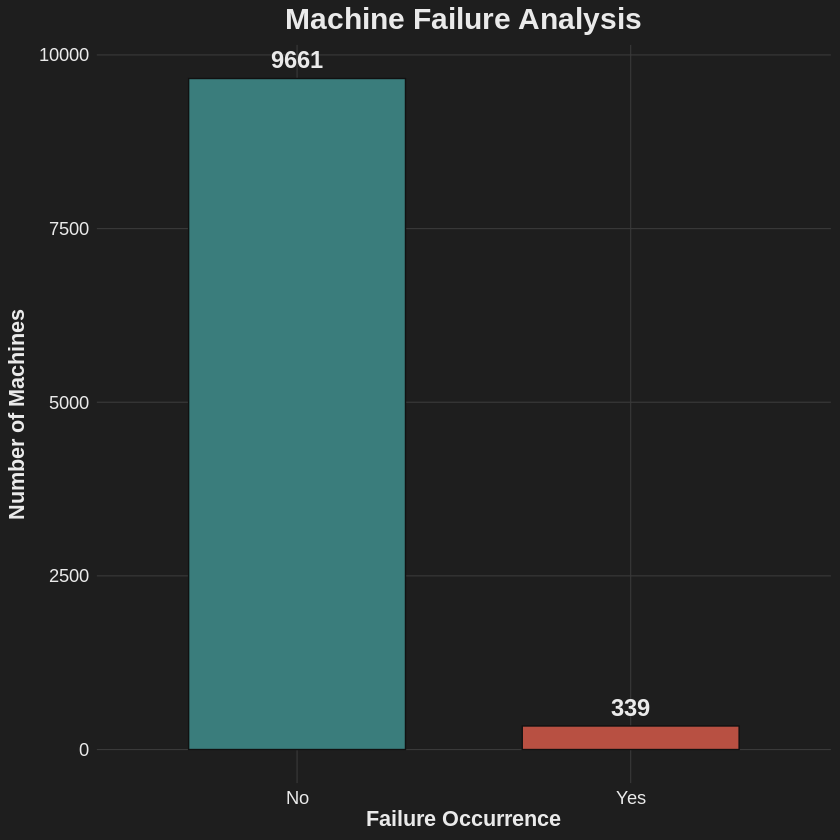

In [57]:
ggplot(data = df, aes(x = Machine.failure, fill = Machine.failure)) +

  geom_bar(
    width = 0.65,
    color = "#111111",
    linewidth = 0.4
  ) +

  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.6,
    size = 5,
    fontface = "bold",
    color = "#EAEAEA"
  ) +

  labs(
    title = "Machine Failure Analysis",
    x = "Failure Occurrence",
    y = "Number of Machines"
  ) +

  scale_x_discrete(
    labels = c(
      "0" = "No",
      "1" = "Yes"
    )
  ) +

  scale_fill_manual(
    values = c(
      "0" = "#3A7D7C",
      "1" = "#B85042"
    )
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

A análise da variável alvo Machine failure revela um cenário de severo desbalanceamento de classes. Em um universo de 10.000 observações, registrou-se apenas 339 eventos de falha (uma taxa de prevalência de 3,4%). Este comportamento de distribuição indica que o conjunto de dados é dominado pela classe majoritária (operação normal), o que estatisticamente tende a viesar o treinamento da Árvore de Decisão, induzindo o modelo a ignorar a classe minoritária (as falhas) em favor de previsões excessivamente otimistas.

####**2.2.2 Tool Wear**

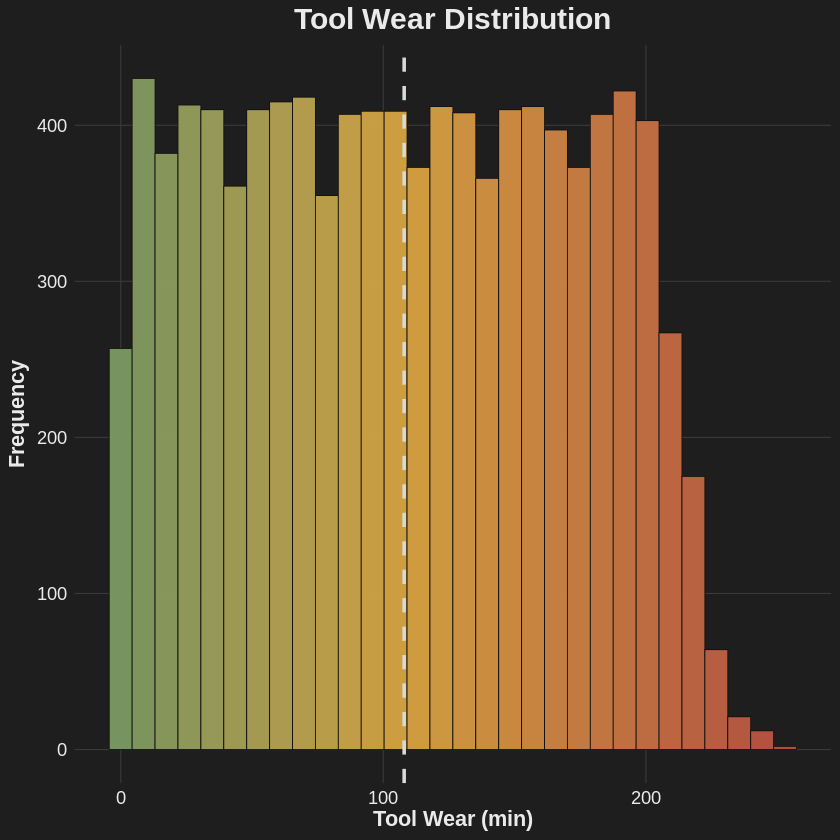

In [58]:
ggplot(data = df, aes(x = Tool.wear..min., fill = after_stat(x))) +

  geom_histogram(
    bins = 30,
    alpha = 0.95,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Tool Wear Distribution",
    x = "Tool Wear (min)",
    y = "Frequency"
  ) +

  scale_fill_gradient2(
    low = "#4C956C",
    mid = "#D9A441",
    high = "#B85042",
    midpoint = mean(df$Tool.wear..min.)
  ) +

  geom_vline(
    aes(xintercept = mean(Tool.wear..min.)),
    color = "#D9D9D9",
    linetype = "dashed",
    linewidth = 1
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

A variável Tool wear apresenta uma distribuição uniforme entre 0 e 200 minutos, seguida por uma queda acentuada na frequência de maquinários operando acima desse limiar. Essa mudança abrupta no padrão sugere uma forte associação estatística entre o desgaste avançado da ferramenta e a ocorrência de falhas (fazendo com que a máquina saia do sistema), ou reflete uma política de manutenção preventiva que interrompe o processo antes que o desgaste atinja níveis críticos.

In [64]:
media <- mean(df$Tool.wear..min.)

moda <- as.numeric(
  names(sort(table(df$Tool.wear..min.), decreasing = TRUE)[1])
)

tabela <- data.frame(
  Estatisticas = c("Média", "Moda"),
  Valor = c(round(media,1), moda)
)
colnames(tabela) <- c("Estatísticas", "Valor")

print(as.data.frame(tabela), row.names = FALSE)

 Estatísticas Valor
        Média   108
         Moda     0


O cálculo das medidas de tendência central para a variável Tool wear revela um comportamento característico de processos cíclicos industriais. Enquanto a média se posiciona em 108 minutos — refletindo de forma equilibrada o valor central esperado devido à distribuição uniforme observada no corpo do gráfico —, a Moda registra o valor de 0 minutos.

Estatisticamente, uma moda nula em variáveis de tempo de desgaste não indica necessariamente uma anomalia, mas sim o ponto de partida do maquinário: o momento em que ferramentas novas ou recém-substituídas entram em operação (reset do contador). A distância entre a moda (0) e a média (108,1) corrobora que, apesar do acúmulo de registros iniciais, o dataset possui uma distribuição relativamente constante ao longo do ciclo de vida útil da ferramenta antes de atingir a zona de declínio após os 200 minutos.

####**2.2.3 Torque (Nm)**

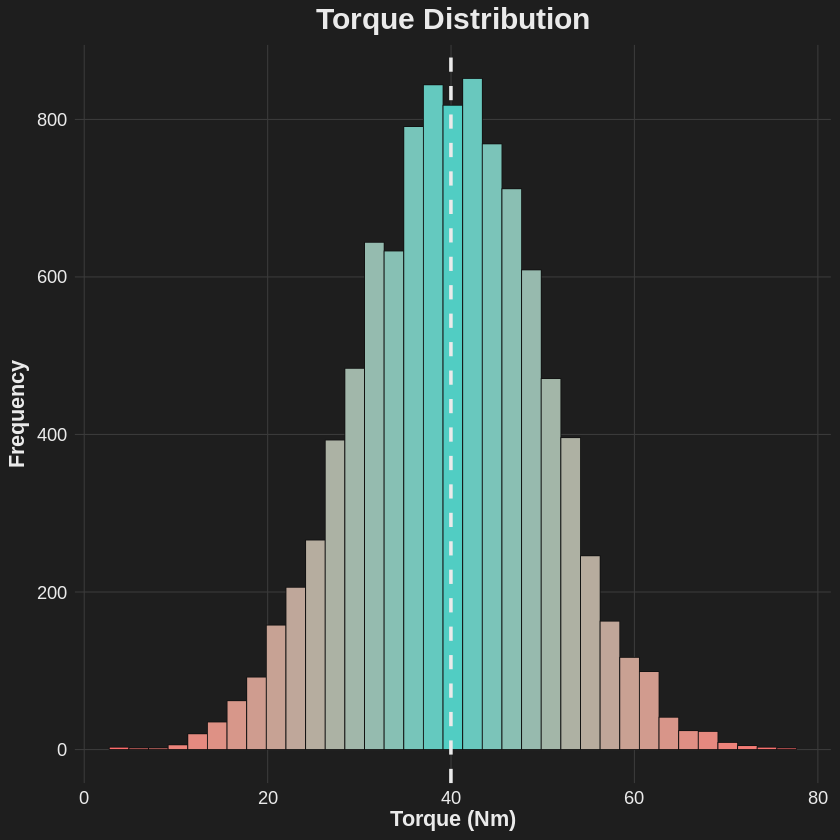

In [68]:
ggplot(
  data = df,
  aes(
    x = Torque..Nm.,
    fill = after_stat(x)
  )
) +

  geom_histogram(
    bins = 35,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Torque Distribution",
    x = "Torque (Nm)",
    y = "Frequency"
  ) +

  scale_fill_gradient2(
    low = "#FF6B6B",
    mid = "#4ECDC4",
    high = "#FF6B6B",
    midpoint = mean(df$Torque..Nm.)
  ) +

  geom_vline(
    aes(xintercept = mean(Torque..Nm.)),
    color = "#EAEAEA",
    linetype = "dashed",
    linewidth = 1
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

A análise univariada do Torque revela um comportamento clássico de Distribuição Normal, caracterizado pela sua simetria em torno do ponto central de 40 Nm, onde a média e a mediana se interceptam. A rápida queda na frequência à medida que nos afastamos do centro demonstra que operações em condições de torque muito baixo ou muito elevado são raras (regiões de cauda), confirmando que o maquinário passa a maior parte do tempo de operação em um regime de esforço mecânico estável e controlado.

####**2.2.4 Rotacional Speed (rpm)**

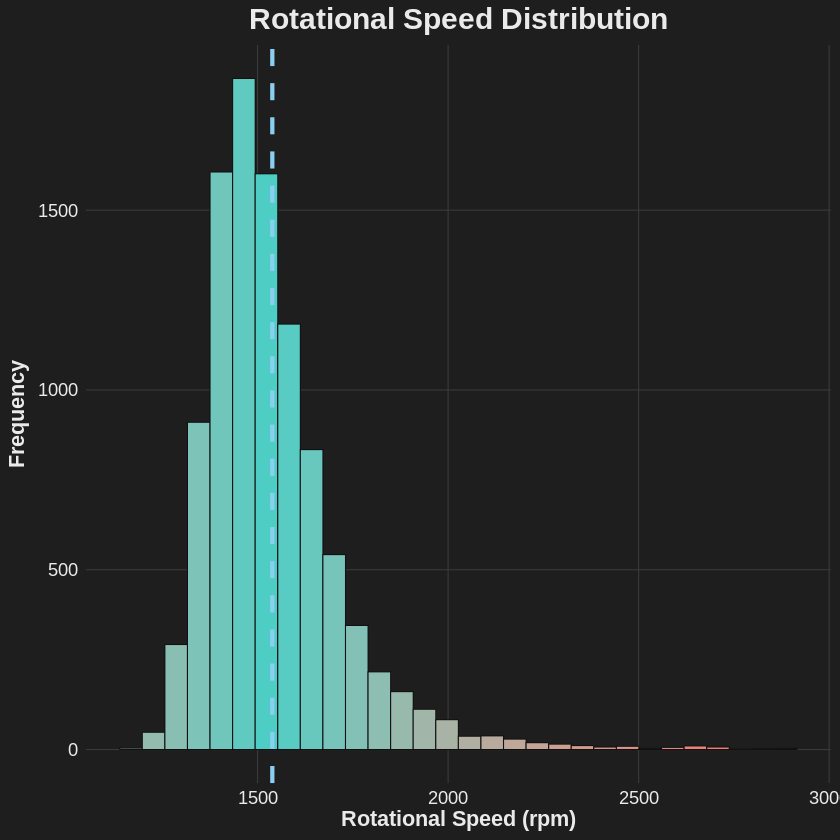

In [76]:
ggplot(
  data = df,
  aes(
    x = Rotational.speed..rpm.,
    fill = abs(after_stat(x) - mean(df$Rotational.speed..rpm.))
  )
) +

  geom_histogram(
    bins = 30,
    color = "#111111",
    linewidth = 0.3
  ) +

  labs(
    title = "Rotational Speed Distribution",
    x = "Rotational Speed (rpm)",
    y = "Frequency"
  ) +

  scale_fill_gradient(
    low = "#4ECDC4",
    high = "#FF6B6B"
  ) +

  geom_vline(
    aes(xintercept = mean(Rotational.speed..rpm.)),
    color = "#89CFF0",
    linetype = "dashed",
    linewidth = 1.2
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

A distribuição da velocidade rotacional apresenta maior concentração em valores intermediários (próximos a 1.500 rpm), decaindo rapidamente para valores baixos, mas estendendo-se em uma cauda longa para valores muito elevados. Isso sugere que, embora a maior parte das máquinas opere em faixas moderadas de rotação, existe um regime importante de operações sob altas velocidades.

####**2.2.5 Air Temperature (°K)**

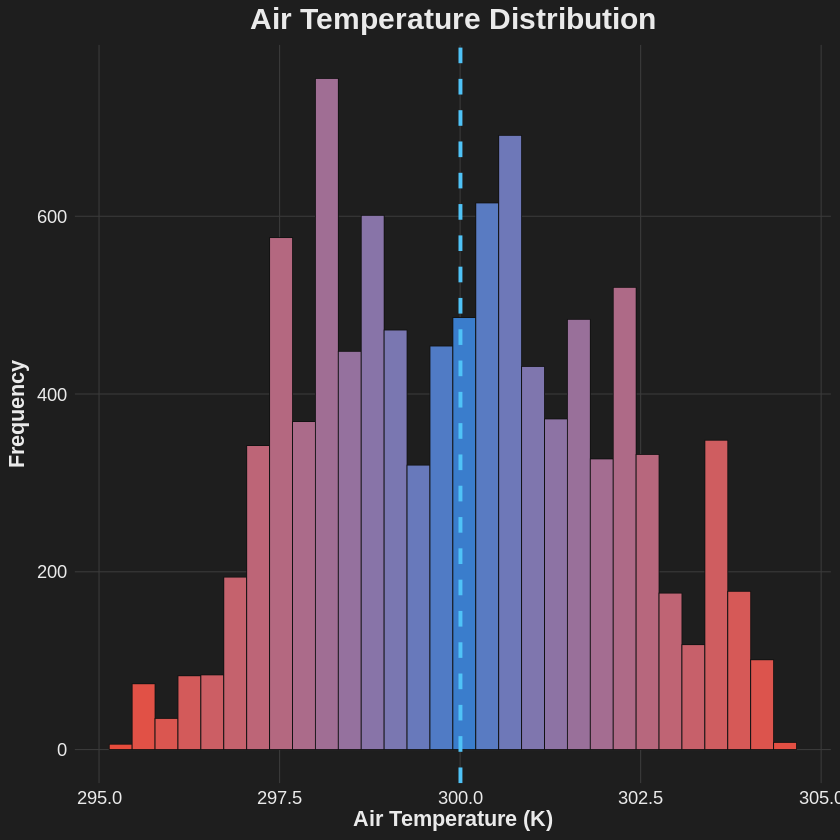

In [75]:
ggplot(
  data = df,
  aes(
    x = Air.temperature..K.,
    fill = abs(after_stat(x) - mean(df$Air.temperature..K.))
  )
) +

  geom_histogram(
    bins = 30,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Air Temperature Distribution",
    x = "Air Temperature (K)",
    y = "Frequency"
  ) +

  scale_fill_gradient(
    low = "#3A7DCC",
    high = "#E74C3C"
  ) +

  geom_vline(
    aes(xintercept = mean(Air.temperature..K.)),
    color = "#4FC3F7",
    linetype = "dashed",
    linewidth = 1.1
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

A distribuição da temperatura do ar apresenta uma forma simétrica (normal) com forte concentração em torno da sua média (300 K), indicando baixa variabilidade nas condições ambientais de operação das máquinas e a ausência de extremos térmicos.

####**2.2.6 Process Temperature**

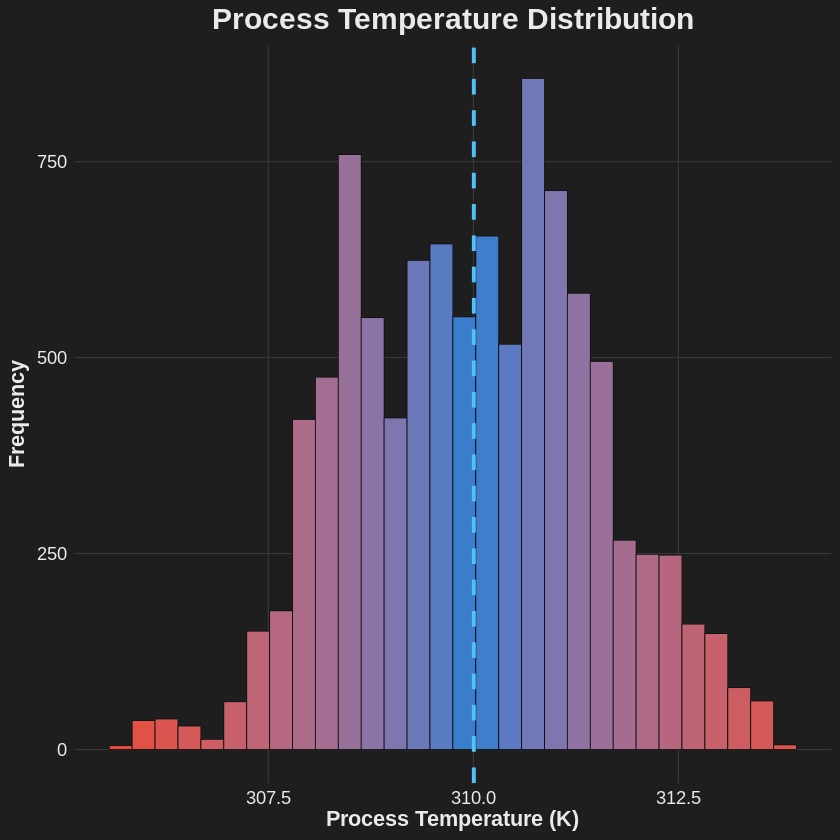

In [89]:
ggplot(
  data = df,
  aes(
    x = Process.temperature..K.,
    fill = abs(after_stat(x) - mean(df$Process.temperature..K.))
  )
) +

  geom_histogram(
    bins = 30,
    color = "#111111",
    linewidth = 0.25
  ) +

  labs(
    title = "Process Temperature Distribution",
    x = "Process Temperature (K)",
    y = "Frequency"
  ) +

  scale_fill_gradient(
    low = "#3A7DCC",
    high = "#E74C3C"
  ) +

  geom_vline(
    aes(xintercept = mean(Process.temperature..K.)),
    color = "#4FC3F7",
    linetype = "dashed",
    linewidth = 1.1
  ) +

  theme_machine() +

  theme(
    legend.position = "none"
  )

O histograma obtido revela um comportamento que se alinha ao modelo teórico de uma **Distribuição Normal Simétrica**. Diferente de outras variáveis do sistema, esta distribuição apresenta uma assimetria praticamente nula ($\text{skewness} \approx 0,01$), resultando em um formato de sino visualmente limpo e bem definido. Essa estabilidade nos valores indica que há um rigoroso controle de temperatura, no qual extremos são raros e podem indicar possíveis falhas.



---



## **Seção 3 - Análise Exploratória de Dados (Bivariada)**